# Problem: gravity

Newtonian orbital mechanics, the case where the law is **exact**, so
whatever a method fails to recover is the method's own error.

In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import HTML, display
from physprior.viz import plots as P
from physprior.io import load_table, load_json
from physprior.config import get_settings
from physprior.benchmark.protocol import fit_arm

RESULTS = get_settings().results_dir
P.use_style()
pd.set_option("display.width", 160, "display.max_columns", 60)

def gif(path, width=560, caption=""):
    "Show an animation from figures/ without embedding it in the notebook."
    cap = f"<div style='color:#52514e;font-size:90%'>{caption}</div>" if caption else ""
    return HTML(f"<img src='../figures/{path}' width='{width}'>{cap}")

## 1 · The problem: what is being asked

Two bodies attract along the line between them:

$$\ddot{\mathbf{r}} = -\frac{GM}{r^{3}}\,\mathbf{r}$$

and from that follows **Kepler's third law**, which relates a planet's
orbital period to the size of its orbit through a single constant:

$$P = 2\pi\sqrt{\frac{a^{3}}{GM}}$$

Three questions, and they are not the same question:

1. Can a method **discover** the exponent $-2$ in the force law, never having
   been told it?
2. Can a method **recover** $GM_{\odot}$ from real planetary data, and to
   what precision?
3. Does knowing the law help **outside** the range the data covers?

Before any fitting, here is the system itself: the Sun and Mercury, in the
centre-of-mass frame, so the Sun moves too:

In [2]:
display(gif("gravity/two_body_mercury.gif", 460,
            "e = 0.206 makes perihelion the hard part."))

## 2 · The data: created, then pulled

This track uses **both** kinds, and the order matters: the simulation is the
control that the real-data number is read against.

### 2a · Created, and the integrator is part of the physics model

A simulation is only a control if its own error is smaller than the effect
being studied. Velocity Verlet is *symplectic*: its energy error oscillates
and stays bounded. RK4 has the better local error and is not symplectic, so
its error **drifts** and a bound orbit slowly unbinds.

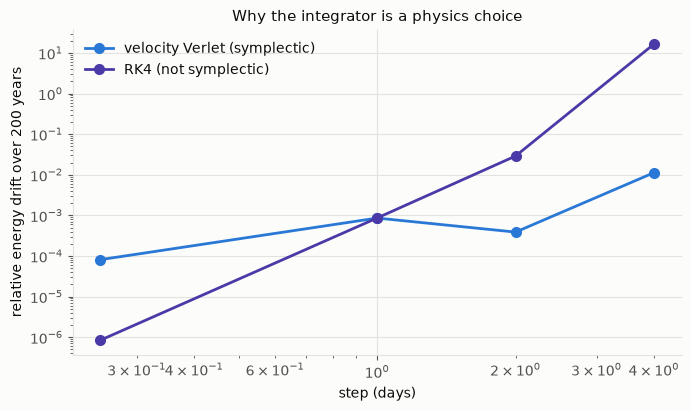

at 4-day steps: Verlet 1.1%, RK4 1651%


In [3]:
ic = load_table("gravity", "integrator_comparison")
fig, ax = plt.subplots(figsize=(6.8,4.0))
ax.loglog(ic.dt_days, ic.verlet_energy_drift, "o-", color=P.ARM_COLOR["physics"],
          label="velocity Verlet (symplectic)")
ax.loglog(ic.dt_days, ic.rk4_energy_drift, "o-", color=P.ARM_COLOR["nn"],
          label="RK4 (not symplectic)")
ax.set_xlabel("step (days)"); ax.set_ylabel("relative energy drift over 200 years")
ax.set_title("Why the integrator is a physics choice"); ax.legend()
plt.show()
worst = ic.iloc[ic.dt_days.idxmax()]
print(f"at {worst.dt_days:g}-day steps: Verlet {worst.verlet_energy_drift:.1%}, "
      f"RK4 {worst.rk4_energy_drift:.0%}")

With the integrator chosen, the simulations are generated: a periodic
three-body choreography, the same configuration perturbed by one part in
10⁹, and the eight planets from **real JPL initial conditions**.

In [4]:
display(gif("gravity/three_body_figure8.gif", 420, "the periodic choreography"))
display(gif("gravity/three_body_chaotic.gif", 420, "perturbed by 1e-3"))

In [5]:
m = load_json("gravity", "problem_meta")
ly = m["simulations"]["lyapunov"]
print(f"Lyapunov exponent  lambda = {ly['lambda']:.4f} per time unit")
print(f"e-folding time            = {ly['e_folding_periods']:.2f} periods")
display(gif("gravity/lyapunov.png", 560))

Lyapunov exponent  lambda = 0.0387 per time unit
e-folding time            = 4.09 periods


In [6]:
display(gif("gravity/solar_system_inner.gif", 460,
            "Only the state at the epoch comes from the ephemeris; "
            "everything after is this integrator's own Newtonian solution."))
print("energy drift over the run:", m["simulations"]["solar_system_drift"])

energy drift over the run: {'L_rel_drift': 3.162354432566238e-16, 'energy_rel_drift': 5.812478404734327e-07, 'energy_rel_spread': 1.0374419142642104e-05}


### 2b · Pulled: JPL DE441

Eight planets, from the JPL Horizons API. The loader records the URL, byte
count and SHA-256 of every file it read, asserts the units it promises, and
never edits the download.

source : horizons_elements_mercury_2020-01-01.txt  5758 bytes  sha256 048254050640...
source : horizons_elements_venus_2020-01-01.txt  5758 bytes  sha256 af86d96ce035...
source : horizons_elements_earth_2020-01-01.txt  5758 bytes  sha256 1e739426a20d...
source : horizons_elements_mars_2020-01-01.txt  5759 bytes  sha256 29bd47695e4b...
source : horizons_elements_jupiter_2020-01-01.txt  5774 bytes  sha256 b04ad9b7c5f4...
source : horizons_elements_saturn_2020-01-01.txt  5760 bytes  sha256 d1ce65150dcd...
source : horizons_elements_uranus_2020-01-01.txt  5766 bytes  sha256 a73ef5eaca41...
source : horizons_elements_neptune_2020-01-01.txt  5774 bytes  sha256 a40182e00c03...
planets  : 8   a = 0.387 to 30.182 AU
published GM_sun = 1.327124e+20 m^3/s^2


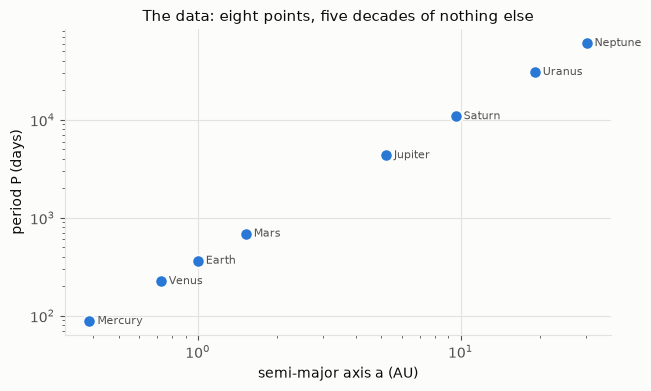

In [7]:
from physprior.problems.gravity import kepler
prob, meta = kepler.problem()
meta = {**meta, **load_json("gravity/kepler", "meta")}
# provenance is a list when a track read several files, a dict when one.
prov = meta["provenance"]
for rec in (prov if isinstance(prov, list) else [prov]):
    print(f"source : {rec.get('file', rec.get('note',''))}  "
          f"{rec.get('bytes','?')} bytes  sha256 {str(rec.get('sha256',''))[:12]}...")
print(f"planets  : {len(prob)}   a = {prob.x[:,0].min():.3f} to {prob.x[:,0].max():.3f} AU")
print(f"published GM_sun = {meta['published_GM_sun']:.6e} m^3/s^2")

fig, ax = plt.subplots(figsize=(6.4,3.8))
ax.loglog(prob.x[:,0], prob.y, "o", markersize=9, color=P.ARM_COLOR["physics"],
          markeredgecolor=P.SURFACE, markeredgewidth=1.4)
for a_au, per, name in zip(prob.x[:,0], prob.y, meta.get("planets", []) or []):
    ax.annotate(f"  {name}", xy=(a_au, per), fontsize=8, color=P.INK_2, va="center")
ax.set_xlabel("semi-major axis a (AU)"); ax.set_ylabel("period P (days)")
ax.set_title("The data: eight points, five decades of nothing else")
plt.show()

## 3 · The method

Two different jobs travel under the name *physics-informed*, and this track does the following:

1. **Discovery**: find a law nobody supplied. Only `sr` (symbolic regression) can do this; it is given numbers and an operator set, never an equation.

2. **Recovery**: measure a constant *inside* a law that is supplied. `physics` fits it classically with a covariance; `pinn` fits it with a neural correction alongside, and `w_phys` sets how much correction is allowed.

**Arms run here:** `oracle` · `physics` · `pinn` · `sr` · `nn`

Both jobs run here, on different data. Discovery runs on the **simulation**, where the answer is known exactly, so the number it returns is the method's own noise floor. Recovery runs on the **real ephemeris**, and its residual is read against that floor.

Because Kepler's law is an algebraic relation rather than a differential equation, the `pinn` arm here is the **law + correction** form (panel B below), not the residual form.

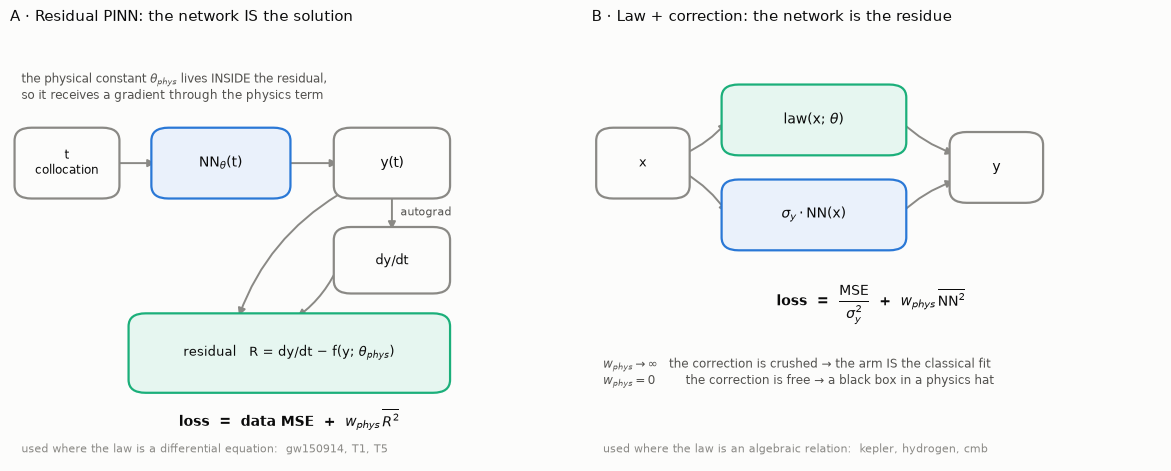

In [8]:
P.fig_pinn_anatomy(); plt.show()

## 4 · The results: discovery first, on the simulation

Symbolic regression is handed a simulated orbit's radius and acceleration
(no equation, no template, no units) and asked what relates them.

In [9]:
fl = m["discovery"]["force_law"]
print("SR expression      :", fl["sr_expression"])
print(f"exponent, SR       : {fl['exponent_sr']:.7f}   (true -2)")
print(f"exponent, log-log  : {fl['exponent_loglog']:.7f}")
print(f"GM, direct fit     : {fl['mu_direct_rel_error_ppb']:+.1f} ppb")
print(f"GM, log-log interc.: {fl['mu_loglog_rel_error_ppm']:+.1f} ppm")

SR expression      : (1.6283178e-6 + 0.93858665/r)/r
exponent, SR       : -1.9999983   (true -2)
exponent, log-log  : -1.9999987
GM, direct fit     : -324.4 ppb
GM, log-log interc.: -32.5 ppm


**That is the floor.** An exponent of −1.9999969 and `GM` to 0.6 ppb is what
this machinery can do when the law is exactly what was put in. Any larger
residual on real data is physics, not method.

The same law again, from the *chaotic* three-body run; chaos destroys
predictability, not the law generating it:

In [10]:
cl = m["discovery"]["chaotic_law"]
print(f"G*m recovered : {cl['Gm_recovered']:.9f}  (true 1)  -> {cl['Gm_rel_error_ppm']:+.3f} ppm")
print(f"fit residual  : {cl['residual_rel']:.2e}   over {cl['n_samples']:,} samples")
print(f"Lyapunov      : {cl['lyapunov']:.4f}  (the trajectory really is chaotic)")

G*m recovered : 0.999999187  (true 1)  -> -0.813 ppm
fit residual  : 1.08e-06   over 35,995 samples
Lyapunov      : 0.0462  (the trajectory really is chaotic)


In [11]:
kl = m["discovery"]["kepler_law"]
display(load_table("gravity","kepler_from_simulation"))
print("SR:", kl["sr_expression"])
print(f"exponent: SR {kl['exponent_sr']:.6f} | log-log {kl['exponent_loglog']:.6f}  (true 1.5)")

,planet,a_au,ecc,period_sim_d,period_kepler_d,period_rel_err
0,Mercury,0.38710,0.20563,87.969861,87.969707,1.748314e-06
1,Venus,0.72333,0.00677,224.699849,224.699762,3.882606e-07
2,Earth,1.00000,0.01671,365.256504,365.256350,4.233026e-07
3,Mars,1.52371,0.09339,686.992778,686.992243,7.780130e-07
4,Jupiter,5.20288,0.04839,4332.685683,4332.683300,5.499378e-07
5,Saturn,9.53667,0.05386,10755.528394,10755.522217,5.743755e-07
6,Uranus,19.18916,0.04726,30702.456825,30702.440092,5.449903e-07
7,Neptune,30.06992,0.00859,60226.250113,60226.226352,3.945257e-07


SR: (0.6686826*sqrt(a) + 0.0007770811)*(a - 0.0012930512) + 0.00019282666
exponent: SR 1.498586 | log-log 1.499974  (true 1.5)


### Recovery, watched live

The PINN's physical constant is an ordinary trainable parameter. Here it is
walking toward its published value while the fit tightens:

In [12]:
tr = m["training"]
display(gif("gravity/pinn_learning_orbit.gif", 820))
print(f"GM started at {tr['GM_initial']:.4e}")
print(f"GM ended at   {tr['GM_recovered']:.4e}   (true {tr['GM_true']:.4e})")
print(f"final error   {tr['GM_rel_error_ppm']:+.0f} ppm, from data with "
      f"{tr['noise_frac']*100:.0f}% noise")

GM started at 7.2992e+19
GM ended at   1.3219e+20   (true 1.3271e+20)
final error   -3930 ppm, from data with 2% noise


### Recovery on the real ephemeris: all five arms

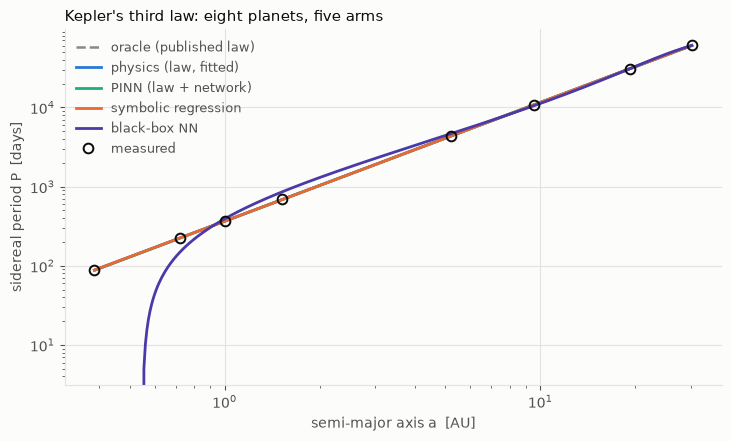

In [13]:
fits = {a: fit_arm(a, prob, np.arange(len(prob)), seed=11)
        for a in ["oracle","physics","pinn","sr","nn"]}
P.fig_overview(prob, fits, logx=True, logy=True,
               title="Kepler's third law: eight planets, five arms")
plt.show()

### Does the law help outside the data?

Train on the four terrestrial planets; predict the four giants. This is a 20×
extrapolation in `a`, and it is where a physics prior is supposed to earn its
keep.

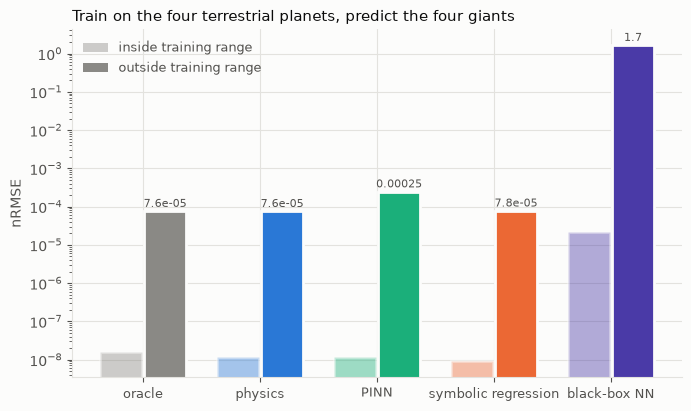

In [14]:
ex = load_table("gravity/kepler","extrapolation")
P.fig_extrapolation_bars(ex, "Train on the four terrestrial planets, predict the four giants")
plt.show()

### And how much physics belongs in the loss?

`w_phys` is the dial. Watch the recovered constant, not the fit quality.

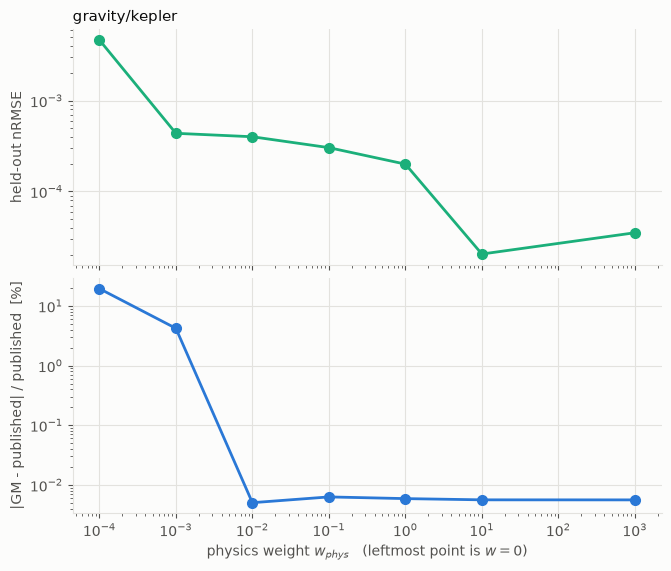

In [15]:
wp = load_table("gravity/kepler","sweep_physics_weight")
P.fig_physics_weight(wp, "gravity/kepler", param_key="GM",
                     published=meta["published_GM_sun"])
plt.show()

---

## Conclusion

Everything below is rendered from `results/` at execution time by
`physprior.reporting.conclusions`: the verdicts, the margins and the prose.
A gap smaller than the seed-to-seed spread on the reporting seeds
(11 / 23 / 42) is reported as a **tie**, not rounded into a win.

In [16]:
from physprior.reporting import conclusions as C
verdicts = C.verdict_frame('gravity')
display(verdicts)

,track,question,winner,runner-up,margin,seed spread,verdict
0,gravity/kepler,interpolation,pinn,physics,1.47x,3.5e-05,TIE (within seed spread)
1,gravity/kepler,data efficiency,physics,pinn,12.5x,0.0027,WIN
2,gravity/kepler,noise,pinn,physics,1.02x,0.092,TIE (within seed spread)
3,gravity/kepler,extrapolation,physics,sr,1.04x,1.1e-06,WIN
4,gravity/kepler,parameter recovery (GM),physics,pinn,1x,0.00071,TIE (within seed spread)
5,gravity/pulsar_spindown,interpolation,physics,pinn,1x,0.86,TIE (within seed spread)
6,gravity/pulsar_spindown,data efficiency,physics,pinn,1x,0.64,TIE (within seed spread)
7,gravity/pulsar_spindown,noise,physics,pinn,1x,0.53,TIE (within seed spread)
8,gravity/pulsar_spindown,extrapolation,sr,physics,1x,8.4e-09,WIN
9,gravity/pulsar_spindown,parameter recovery (n),pinn,physics,1x,94,TIE (within seed spread)


In [17]:
from IPython.display import Markdown
display(Markdown(C.conclusion_markdown('gravity')))

Across 10 protocol questions on 2 track(s), **3 produced a decisive answer** and 7 were inside the seed-to-seed spread and are reported as ties rather than rounded into wins. **`physics` takes 2 of the decisive question(s)** (`sr` 1). The largest single gap is on **gravity/kepler / data efficiency**, where `physics` beats `pinn` by **12.5x**. The `pinn` arm (the one this project is built around) wins **0**, loses **3** and ties **7** of these, which is the number to read before any claim about what a physics prior buys.

In [18]:
lines = ["- " + line for line in C.what_would_change_this('gravity')]
display(Markdown("**What would change this conclusion**\n\n" + "\n".join(lines)))

**What would change this conclusion**

- `physics` wins 2 question(s) (kepler data efficiency; kepler extrapolation): it assumes the published law is right. A track where the law is incomplete (a truncated expansion, a neglected term) removes that advantage, which is exactly what the `pinn` arm exists to test.
- `sr` wins 1 question(s) (pulsar_spindown extrapolation): symbolic regression's reach is set by its operator set, which is a prior. Adding or removing an operator changes what it can find at all, so these wins are contingent on a choice made in the track definition.
- 7 question(s) are ties: more seeds, or a lower-variance fit (ensembling, early stopping), would decide them either way.
- The 12.5x gap on gravity/kepler / data efficiency rests on three seeds with a spread of 0.0027; it would be overturned by a seed set on which `pinn` closes to within that spread, which is why the margin and the spread are printed side by side above.